# Implement PCA and Explore Corpus (REWRITE HEADER?)

Notes:

I am following along with my M07 02 PCA with SKL Notes and my M07 HW as I complete this section.

## Setup

### Import Libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD

In [2]:
import plotly.express as px
import plotly.io as pio

sns.set_theme(style='white')
pio.renderers.default = 'vscode'

### Configuration

### Load Data

In [3]:
# load in tables
LIB = pd.read_csv('data/LIB.csv', sep='\t').set_index('book_id')
TFIDF_L2 = pd.read_csv('data/TFIDF_L2.csv', sep='\t').set_index(['book_id', 'chap_num']) # recall this is TFIDF_reduced L2 normalized

## Run PCA

Pass the TFIDF table with reduced feature space SKLearn's PCA class.

### Instantiate PCA Engine

I will start with default values for the constructor, and will set random_state to 36 and the number of components to 20. Then I will plot the cumulative explained variance, and then refit with my chosen number of components where the curve begins to flatten out.

/tmp/ipykernel_572120/4086206609.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


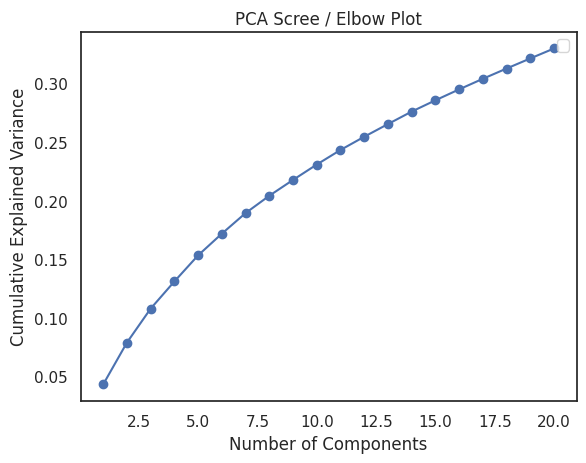

In [4]:
# instantiate PCA engine with defaults except random_state=36 and n_components=20
pca_explore = PCA(n_components=20, random_state=36)
pca_explore.fit(TFIDF_L2)

cumvar = np.cumsum(pca_explore.explained_variance_ratio_)

plt.plot(range(1, len(cumvar)+1), cumvar, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree / Elbow Plot')
plt.legend()
plt.show()

This scree plot doesn't have a pronounced elbow. Variance is accumulating slowly across components. I am choosing ten components as a practical limit to balance variance coverage and interpretability. 

In [5]:
# reinstantiate PCA engine with defaults except random_state=36 and n_components=10
pca_engine = PCA(n_components = 10, random_state = 36)

### Build PCA Document-Component Matrix (DCM)

Fit and transform the normalized, reduced TFIDF data (TFIDF_L2) to create the document component matrix.

In [6]:
# fit and transform the normalized reduced TFIDF data (pass it to PCA engine) to create document component matrix
DCM = pd.DataFrame(
    pca_engine.fit_transform(TFIDF_L2),
    index = TFIDF_L2.index # pca engine returns a numpy matrix which we turn back into a dataframe
)

DCM.columns = [f'PC{i}' for i in range(DCM.shape[1])]

# DCM # now we have a document component matrix

### Build PCA Loadings (Component-Term Matrix)

Create a data frame LOADINGS that contains terms as observations and components as features.

Here is the formula from our M07 HW: `pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_)`

In [7]:
# create LOADINGS dataframe with terms as observations and components as features

LOADINGS = pd.DataFrame(
    pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_),
    index = TFIDF_L2.columns,
    # use PC column names from DCM
    columns = DCM.columns
)

# confirm index name is 'term_str' (don't actually need bc this came through via BOW initially?)
LOADINGS.index.name = 'term_str'

# LOADINGS

### Create a DOC data frame for Visualization

I will now create a DOC table from the DCM index in which each row represents a bag (in this case chapter).

It will have ['book_id', 'chap_num'] as its index.

This table will have information from the LIB table joined to it, so that each chapter is identified with title, sleuth, original publication year, work type, and genre.

Finally, I will add a DOC feature label that is a string which concatenates book_id and chapter.

These data will appear in my visualizations.

In [8]:
# create initial DOC table with DCM index
DOC = pd.DataFrame(index=DCM.index)

# join metadata from LIB (join on book_id)
DOC = DOC.join(LIB[['title', 'sleuth', 'pub_year_original', 'work_type', 'genre']], on='book_id')

# create label column
book_str = DOC.index.get_level_values('book_id')
chap_str = DOC.index.get_level_values('chap_num').astype(str)

DOC['label'] = book_str + ' ch.' + chap_str

In [9]:
# extract primary genre
DOC['primary_genre'] = DOC['genre'].str.split('|').str[0]

# DOC

## Visualize

### PCA Visualization 1

TODO: 
- Include a scatterplot of documents in the space created by the first two components.
    - Color the points based on a metadata feature associated with the documents.
- Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)
- Briefly describe the nature of the polarity you see in the first component:

#### Scatterplot of documents in the space created by the first two components

With points colored by metadata features.

In [10]:
# create a scatterplot of documents in the space created by the first 2 components
# coloring the points by sleuth

# fill the NaN for works without a sleuth (Giant's Bread)
DOC['sleuth'] = DOC['sleuth'].fillna('None')

px.scatter(
    data_frame = DCM.join(DOC).reset_index(),
    x = 'PC0', # first PC
    y = 'PC1', # second PC
    color = 'sleuth', # color by sleuth
    hover_name = 'label', # use concat string for hover info
    hover_data=['pub_year_original', 'work_type', 'primary_genre'], # add more hover data
    marginal_x = 'box' # add boxplot to x axis
)

In [11]:
# # create a scatterplot of documents in the space created by the first 2 components
# # coloring the points by primary_genre

# px.scatter(
#     data_frame = DCM.join(DOC).reset_index(),
#     x = 'PC0', # first PC
#     y = 'PC1', # second PC
#     color = 'primary_genre', # color by primary_genre
#     hover_name = 'label', # use concat string for hover info
#     hover_data=['sleuth', 'pub_year_original', 'work_type'], # add more hover data
#     marginal_x = 'box' # add boxplot to x axis
# )

In [12]:
# # create a scatterplot of documents in the space created by the first 2 components
# # coloring the points by book_id

# px.scatter(
#     data_frame = DCM.join(DOC).reset_index(),
#     x = 'PC0', # first PC
#     y = 'PC1', # second PC
#     color = 'book_id', # color by book_id
#     hover_name = 'label', # use concat string for hover info
#     hover_data=['sleuth', 'pub_year_original', 'work_type', 'primary_genre'], # add more hover data
#     marginal_x = 'box' # add boxplot to x axis
# )

In [13]:
# # create a scatterplot of documents in the space created by the first 2 components
# # coloring the points by work_type

# px.scatter(
#     data_frame = DCM.join(DOC).reset_index(),
#     x = 'PC0', # first PC
#     y = 'PC1', # second PC
#     color = 'work_type', # color by work_type
#     hover_name = 'label', # use concat string for hover info
#     hover_data=['sleuth', 'pub_year_original', 'primary_genre'], # add more hover data
#     marginal_x = 'box' # add boxplot to x axis
# )

In [14]:
# # create a scatterplot of documents in the space created by the first 2 components
# # coloring the points by pub_year_original

# px.scatter(
#     data_frame = DCM.join(DOC).reset_index(),
#     x = 'PC0', # first PC
#     y = 'PC1', # second PC
#     color = 'pub_year_original', # color by pub_year_original
#     hover_name = 'label', # use concat string for hover info
#     hover_data=['sleuth', 'work_type', 'primary_genre'], # add more hover data
#     marginal_x = 'box' # add boxplot to x axis
# )

#### Scatterplot of the loadings for the first two components

In [15]:
px.scatter(
    data_frame = LOADINGS.reset_index(),
    x = 'PC0', # first PC
    y = 'PC1', # second PC
    hover_name = 'term_str',
    marginal_x = 'box'
)

In [16]:
print(LOADINGS['PC0'].sort_values().head(10))  # most negative
print(LOADINGS['PC0'].sort_values().tail(10))  # most positive

term_str
monsieur       -0.048511
madame         -0.047142
hastings       -0.033820
mademoiselle   -0.030841
mon            -0.019916
train          -0.019592
ami            -0.018493
friend         -0.016563
four           -0.015716
crime          -0.015448
Name: PC0, dtype: float64
term_str
really    0.008895
couldn    0.010784
want      0.010990
seven     0.011598
didn      0.014183
lady      0.016524
re        0.018239
george    0.048285
lord      0.050949
bill      0.095035
Name: PC0, dtype: float64


Note the many of the negative loadings for PC0 are term strings that are French terms of address, or are otherwise words often used by Poirot such as "friend". We also see "hastings" here, which is associated with Poirot's good friend and the narrator of most Poirot books, Hastings. It is also likely that "four" shows up here because of its frequent use in The Big Four (a Poirot novel). 

In [17]:
print(LOADINGS['PC1'].sort_values().head(10))  # most negative
print(LOADINGS['PC1'].sort_values().tail(10))  # most positive

term_str
colonel     -0.061483
inspector   -0.031965
didn        -0.021135
re          -0.017846
mother      -0.016195
dr          -0.014722
want        -0.014208
really      -0.014017
couldn      -0.013913
mary        -0.011912
Name: PC1, dtype: float64
term_str
mon             0.011479
train           0.011611
hastings        0.014129
lady            0.015162
mademoiselle    0.024164
george          0.029703
lord            0.040897
monsieur        0.042587
madame          0.043550
bill            0.068229
Name: PC1, dtype: float64


#### Brief description of the nature of the polarity seen in the first component

### PCA Visualization 2

## PCA Visualization 2 (4)

TODO:
- Include a scatterplot of documents in the space created by the second two components.
    - Color the points based on a metadata feature associated with the documents.
- Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)
- Briefly describe the nature of the polarity you see in the second component:

#### Scatterplot of documents in the space created by the second two components

With points colored by metadata features.

In [18]:
# create a scatterplot of documents in the space created by the first 2 components
# coloring the points by sleuth

# fill the NaN for works without a sleuth (Giant's Bread)
DOC['sleuth'] = DOC['sleuth'].fillna('None')

px.scatter(
    data_frame = DCM.join(DOC).reset_index(),
    x = 'PC2', # third PC
    y = 'PC3', # fourth PC
    color = 'sleuth', # color by sleuth
    hover_name = 'label', # use concat string for hover info
    hover_data=['pub_year_original', 'work_type', 'primary_genre'], # add more hover data
    marginal_x = 'box' # add boxplot to x axis
)

In [19]:
# MAY NOT NEED ALL OF THESE

# create a scatterplot of documents in the space created by the second 2 components
# coloring the points by primary_genre

px.scatter(
    data_frame = DCM.join(DOC).reset_index(),
    x = 'PC2', # third PC
    y = 'PC3', # fourth PC
    color = 'primary_genre', # color by primary_genre
    hover_name = 'label', # use concat string for hover info
    hover_data=['sleuth', 'pub_year_original', 'work_type'], # add more hover data
    marginal_x = 'box' # add boxplot to x axis
)

In [20]:
# MAY NOT NEED ALL OF THESE

# create a scatterplot of documents in the space created by the second 2 components
# coloring the points by book_id

px.scatter(
    data_frame = DCM.join(DOC).reset_index(),
    x = 'PC2', # third PC
    y = 'PC3', # fourth PC
    color = 'book_id', # color by book_id
    hover_name = 'label', # use concat string for hover info
    hover_data=['sleuth', 'pub_year_original', 'work_type', 'primary_genre'], # add more hover data
    marginal_x = 'box' # add boxplot to x axis
)

In [21]:
# # create a scatterplot of documents in the space created by the second 2 components
# # coloring the points by work_type

# px.scatter(
#     data_frame = DCM.join(DOC).reset_index(),
#     x = 'PC2', # third PC
#     y = 'PC3', # fourth PC
#     color = 'work_type', # color by work_type
#     hover_name = 'label', # use concat string for hover info
#     hover_data=['sleuth', 'pub_year_original', 'primary_genre'], # add more hover data
#     marginal_x = 'box' # add boxplot to x axis
# )

In [22]:
# # create a scatterplot of documents in the space created by the second 2 components
# # coloring the points by pub_year_original

# px.scatter(
#     data_frame = DCM.join(DOC).reset_index(),
#     x = 'PC2', # third PC
#     y = 'PC3', # fourth PC
#     color = 'pub_year_original', # color by pub_year_original
#     hover_name = 'label', # use concat string for hover info
#     hover_data=['sleuth', 'work_type', 'primary_genre'], # add more hover data
#     marginal_x = 'box' # add boxplot to x axis
# )

#### Scatterplot of the loadings for the second two components

In [23]:
px.scatter(
    data_frame = LOADINGS.reset_index(),
    x = 'PC2', # third PC
    y = 'PC3', # fourth PC
    hover_name = 'term_str',
    marginal_x = 'box'
)

#### Brief description of the nature of the polarity seen in the first component

## Save Outputs

In [24]:
# # save the updated VOCAB table to csv (replace the existing one created by 03-VOCAB.ipynb)
# VOCAB.to_csv('data/VOCAB.csv', sep='\t', index=True)

# # save the BOW table to csv
# BOW_chaps.to_csv('data/BOW_chaps.csv', sep='\t', index=True)

# # save the DTM table to csv
# DTM.to_csv('data/DTM.csv', sep='\t', index=True)

# # save the TFIDF table to csv
# TFIDF.to_csv('data/TFIDF.csv', sep='\t', index=True)

# # save the TFIDF_L2 table to csv
# TFIDF_L2.to_csv('data/TFIDF_L2.csv', sep='\t', index=True)